# Jupyter notebooks

Here, we explain how to visualize VeloxChem results in Jupyter notebooks. 

The underlying calculation can be obtained either directly in a notebook or imported from a VeloxChem `.h5` file.

In [1]:
import veloxchem as vlx

## Molecular structure

In Jupyter notebook, a molecule object can be visualized using the show function. 

The `atom_indices` and `atom_labels` options can be used.

**From a notebook cell**

In [2]:
molecule = vlx.Molecule.read_smiles('C1=CC=C(C=C1)C(=O)O')

molecule.show(atom_indices=True, atom_labels=True)

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

**From an h5 file**

In [3]:
molecule, basis = vlx.read_molecule_and_basis("../output_files/biphenyl-scf.h5")

molecule.show()

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

## Structure optimization


**From notebook cell**

In [4]:
molecule = vlx.Molecule.read_smiles('CCO')
basis = vlx.MolecularBasis.read(molecule, 'def2-svp')

scf_drv = vlx.ScfRestrictedDriver()
scf_drv.xcfun = 'b3lyp'
results = scf_drv.compute(molecule, basis)

opt_drv = vlx.OptimizationDriver(scf_drv)
opt_results = opt_drv.compute(molecule, basis, results)

                                                                                                                          
                                            Self Consistent Field Driver Setup                                            
                                                                                                                          
                   Wave Function Model             : Spin-Restricted Kohn-Sham                                            
                   Initial Guess Model             : Superposition of Atomic Densities                                    
                   Convergence Accelerator         : Two Level Direct Inversion of Iterative Subspace                     
                   Max. Number of Iterations       : 50                                                                   
                   Max. Number of Error Vectors    : 10                                                                   
                

In [5]:
opt_drv.show_convergence(opt_results)

interactive(children=(IntSlider(value=7, description='step', max=7), Output()), _dom_classes=('widget-interact…

**From an h5 file**

In [6]:
opt_results = vlx.read_results("../output_files/bithio-S0-opt.h5", label="opt")
opt_drv.show_convergence(opt_results)

interactive(children=(IntSlider(value=13, description='step', max=13), Output()), _dom_classes=('widget-intera…

## Spectrum plotting


**From a notebook cell**

In [7]:
molecule = vlx.Molecule.read_smiles('CCO')
basis = vlx.MolecularBasis.read(molecule, 'def2-svp')

scf_drv = vlx.ScfRestrictedDriver()
scf_drv.xcfun = 'b3lyp'
scf_results = scf_drv.compute(molecule, basis)

rsp_drv = vlx.lreigensolver.LinearResponseEigenSolver()
rsp_drv.nstates = 10
rsp_results = rsp_drv.compute(molecule, basis, scf_results)

                                                                                                                          
                                            Self Consistent Field Driver Setup                                            
                                                                                                                          
                   Wave Function Model             : Spin-Restricted Kohn-Sham                                            
                   Initial Guess Model             : Superposition of Atomic Densities                                    
                   Convergence Accelerator         : Two Level Direct Inversion of Iterative Subspace                     
                   Max. Number of Iterations       : 50                                                                   
                   Max. Number of Error Vectors    : 10                                                                   
                

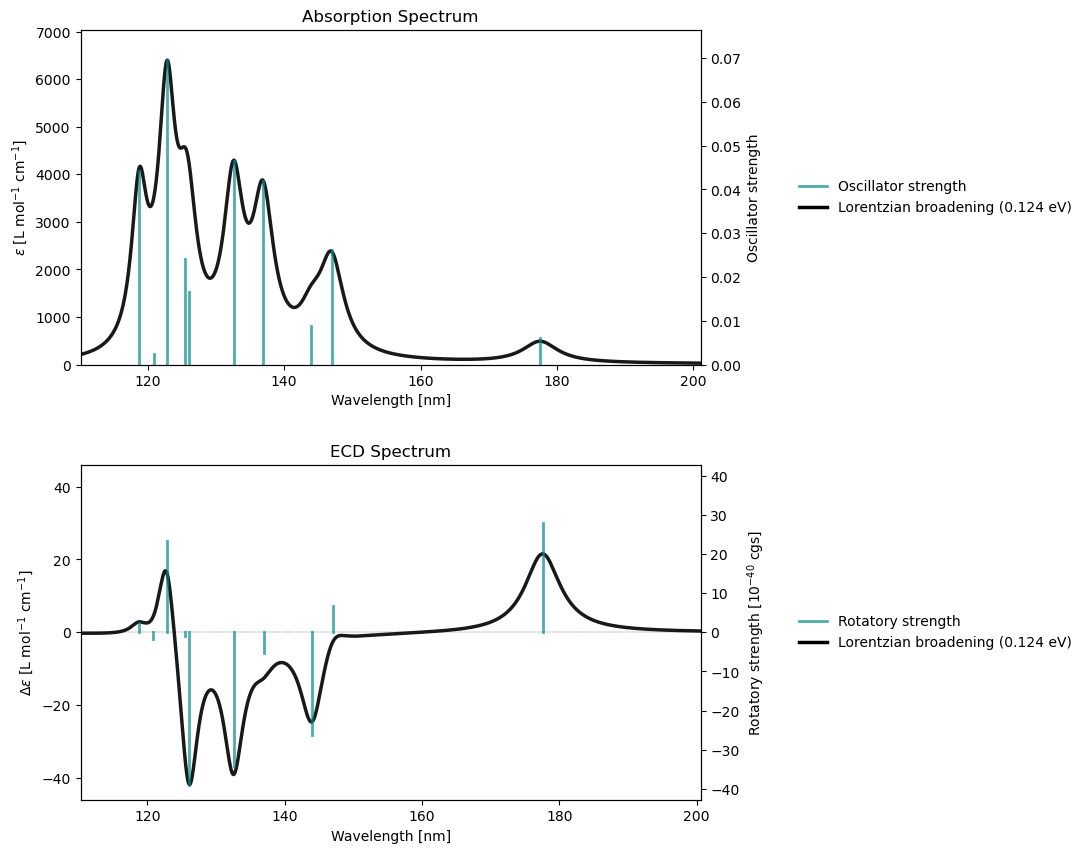

In [8]:
rsp_drv.plot(rsp_results)

**From an h5 file**

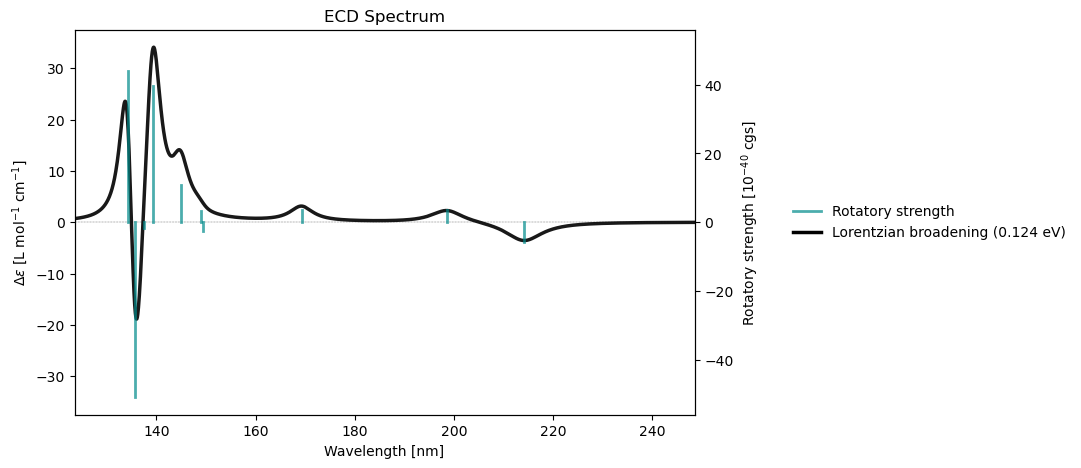

In [9]:
rsp_results = vlx.read_results("../output_files/alanine-ecd.h5", label="rsp")
rsp_drv.plot_ecd(rsp_results)

## Normal modes

**From a notebook cell**

In [10]:
molecule = vlx.Molecule.read_smiles('CCO')
basis = vlx.MolecularBasis.read(molecule, 'def2-svp')

scf_drv = vlx.ScfRestrictedDriver()
scf_drv.xcfun = 'b3lyp'
scf_results = scf_drv.compute(molecule, basis)

vib_drv = vlx.VibrationalAnalysis(scf_drv)
vib_results = vib_drv.compute(molecule, basis)

                                                                                                                          
                                            Self Consistent Field Driver Setup                                            
                                                                                                                          
                   Wave Function Model             : Spin-Restricted Kohn-Sham                                            
                   Initial Guess Model             : Superposition of Atomic Densities                                    
                   Convergence Accelerator         : Two Level Direct Inversion of Iterative Subspace                     
                   Max. Number of Iterations       : 50                                                                   
                   Max. Number of Error Vectors    : 10                                                                   
                

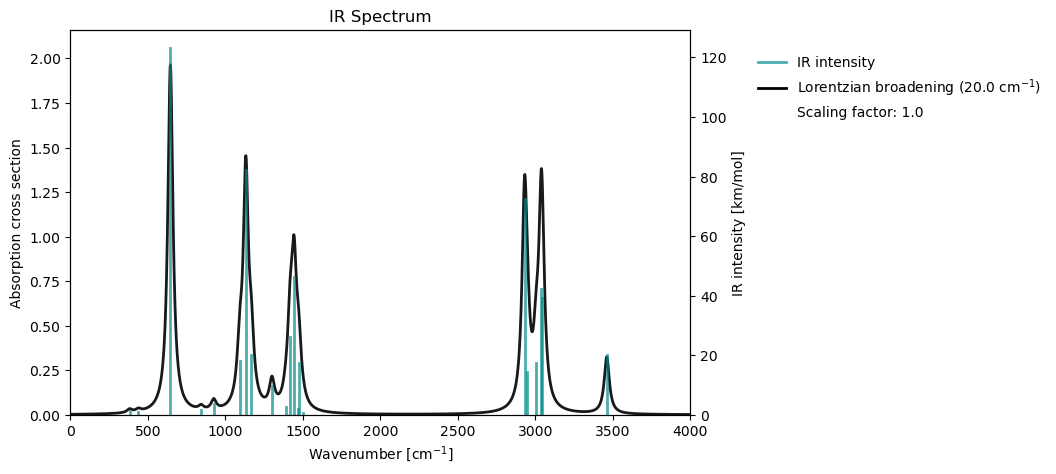

In [11]:
vib_drv.plot(vib_results)

In [12]:
vib_drv.animate(vib_results, mode=14)

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

**From an h5 file**

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

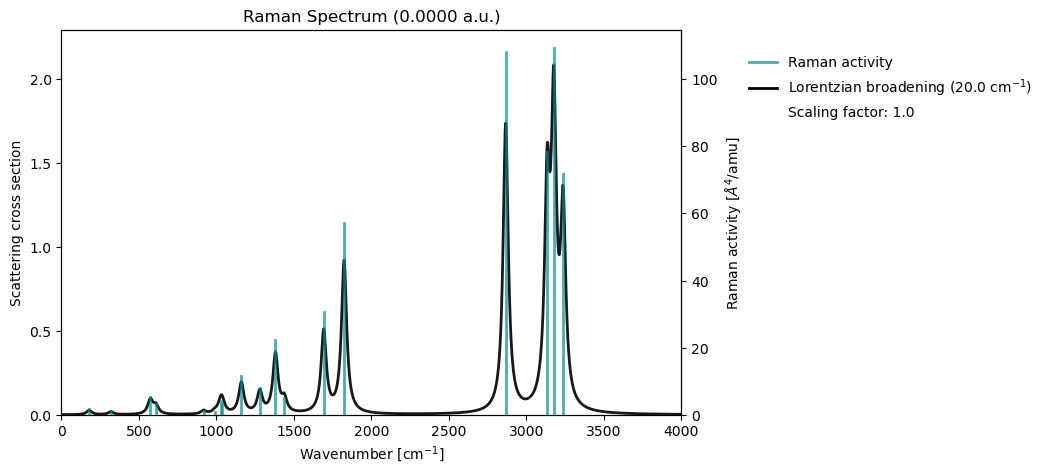

In [13]:
vib_results = vlx.read_results("../output_files/acro-raman.h5", label="vib")
vib_drv.plot_raman(vib_results)
vib_drv.animate(vib_results, mode=14)